In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

print("="*80)
print("Q3: FEATURE ENGINEERING & REGRESSION PIPELINE")
print("="*80)

Q3: FEATURE ENGINEERING & REGRESSION PIPELINE


In [2]:
df = pd.read_csv('q3_retail_promotions.csv')

print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nData types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())
print("\nBasic statistics:")
print(df.describe())

Dataset shape: (1200, 9)

First 5 rows:
  transaction_date  store_id store_size location_type  promotion_type  \
0       2022-01-01        28      small    semi-urban       free_gift   
1       2022-01-01         5     medium    semi-urban       free_gift   
2       2022-01-02        13      small    semi-urban  loyalty_points   
3       2022-01-02        17      small         urban       free_gift   
4       2022-01-03        50     medium    semi-urban            bogo   

   is_weekend  is_festival  competition_density  items_sold  
0           1            0                    5         224  
1           1            1                    1         348  
2           1            0                    6         249  
3           1            0                    7         259  
4           0            0                    3         277  

Data types:
transaction_date       object
store_id                int64
store_size             object
location_type          object
promotion_type  

# ***Task 1 - Date Feature Engineering***

In [3]:
print("\n" + "="*80)
print("TASK 1: DATE FEATURE ENGINEERING")
print("="*80)

# Convert transaction_date to datetime
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

# Extract date features
df['year'] = df['transaction_date'].dt.year
df['month'] = df['transaction_date'].dt.month
df['day_of_week'] = df['transaction_date'].dt.dayofweek  # 0=Monday, 6=Sunday

# Create month-end feature (1 if day >= 25, else 0)
df['is_month_end'] = (df['transaction_date'].dt.day >= 25).astype(int)

# Display sample of new features
print("\nSample of engineered features:")
print(df[['transaction_date', 'year', 'month', 'day_of_week', 'is_month_end']].head(10))

print(f"\nNew dataset shape: {df.shape}")
print("\nFeatures created:")
print("  ✓ year: Year of transaction (2022, 2023, etc.)")
print("  ✓ month: Month (1=Jan, 12=Dec)")
print("  ✓ day_of_week: Day of week (0=Mon, 6=Sun)")
print("  ✓ is_month_end: Binary flag for month-end (day >= 25)")


TASK 1: DATE FEATURE ENGINEERING

Sample of engineered features:
  transaction_date  year  month  day_of_week  is_month_end
0       2022-01-01  2022      1            5             0
1       2022-01-01  2022      1            5             0
2       2022-01-02  2022      1            6             0
3       2022-01-02  2022      1            6             0
4       2022-01-03  2022      1            0             0
5       2022-01-03  2022      1            0             0
6       2022-01-04  2022      1            1             0
7       2022-01-04  2022      1            1             0
8       2022-01-05  2022      1            2             0
9       2022-01-05  2022      1            2             0

New dataset shape: (1200, 13)

Features created:
  ✓ year: Year of transaction (2022, 2023, etc.)
  ✓ month: Month (1=Jan, 12=Dec)
  ✓ day_of_week: Day of week (0=Mon, 6=Sun)
  ✓ is_month_end: Binary flag for month-end (day >= 25)


# ***Task 2 - Temporal Train-Test Split***

In [4]:
print("\n" + "="*80)
print("TASK 2: TEMPORAL TRAIN-TEST SPLIT")
print("="*80)

# Sort by transaction date to maintain temporal order
df = df.sort_values('transaction_date').reset_index(drop=True)

# Calculate split point (80% train, 20% test)
n = len(df)
split_idx = int(n * 0.8)

# Create train-test split based on temporal order
train_df = df.iloc[:split_idx].copy()
test_df = df.iloc[split_idx:].copy()

print(f"\nTotal records: {n}")
print(f"Train set: {len(train_df)} records ({len(train_df)/n*100:.1f}%)")
print(f"Test set: {len(test_df)} records ({len(test_df)/n*100:.1f}%)")

print(f"\nTrain date range: {train_df['transaction_date'].min()} to {train_df['transaction_date'].max()}")
print(f"Test date range: {test_df['transaction_date'].min()} to {test_df['transaction_date'].max()}")


TASK 2: TEMPORAL TRAIN-TEST SPLIT

Total records: 1200
Train set: 960 records (80.0%)
Test set: 240 records (20.0%)

Train date range: 2022-01-01 00:00:00 to 2024-06-11 00:00:00
Test date range: 2024-06-12 00:00:00 to 2024-12-31 00:00:00


# ***Task 3 - Define Features***

In [5]:
print("\n" + "="*80)
print("TASK 3: PREPROCESSING PIPELINE - PART A: FEATURE DEFINITION")
print("="*80)

# Define categorical features
categorical_features = ['promotion_type', 'location_type', 'store_size']
print(f"\nCategorical features ({len(categorical_features)}): {categorical_features}")

# Define numerical features
numerical_features = ['store_id', 'is_weekend', 'is_festival', 'competition_density',
                      'year', 'month', 'day_of_week', 'is_month_end']
print(f"Numerical features ({len(numerical_features)}): {numerical_features}")

# Prepare X and y
X_train = train_df[categorical_features + numerical_features].copy()
y_train = train_df['items_sold'].copy()

X_test = test_df[categorical_features + numerical_features].copy()
y_test = test_df['items_sold'].copy()

print(f"\nTrain set shapes:")
print(f"  X_train: {X_train.shape}")
print(f"  y_train: {y_train.shape}")

print(f"\nTest set shapes:")
print(f"  X_test: {X_test.shape}")
print(f"  y_test: {y_test.shape}")

print(f"\nTotal features before preprocessing: {X_train.shape[1]}")


TASK 3: PREPROCESSING PIPELINE - PART A: FEATURE DEFINITION

Categorical features (3): ['promotion_type', 'location_type', 'store_size']
Numerical features (8): ['store_id', 'is_weekend', 'is_festival', 'competition_density', 'year', 'month', 'day_of_week', 'is_month_end']

Train set shapes:
  X_train: (960, 11)
  y_train: (960,)

Test set shapes:
  X_test: (240, 11)
  y_test: (240,)

Total features before preprocessing: 11


# ***Task 3 - Create Pipeline***

In [6]:
print("\n" + "="*80)
print("TASK 3: PREPROCESSING PIPELINE - PART B: CREATE PIPELINE")
print("="*80)

# Create preprocessing pipeline using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        # Categorical: One-Hot Encoding
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features),
        # Numerical: Standard Scaling
        ('num', StandardScaler(), numerical_features)
    ]
)

print("\nColumnTransformer configuration:")
print(f"  Step 1 (cat): OneHotEncoder")
print(f"    ├─ Input: {categorical_features}")
print(f"    ├─ drop='first': Remove first category to avoid multicollinearity")
print(f"    └─ Output: Binary columns for each category")
print(f"\n  Step 2 (num): StandardScaler")
print(f"    ├─ Input: {numerical_features}")
print(f"    ├─ Formula: (X - mean) / std_dev")
print(f"    └─ Output: Scaled features (mean=0, std=1)")

print("\nWhy StandardScaler for numerical features?")
print("""
  • TreeL features like 'store_id' (1-50) vs 'competition_density' (0-10)
  • Without scaling: store_id dominates distance calculations
  • With scaling: All features contribute equally
  • Important for: Linear regression, distance-based algorithms
""")


TASK 3: PREPROCESSING PIPELINE - PART B: CREATE PIPELINE

ColumnTransformer configuration:
  Step 1 (cat): OneHotEncoder
    ├─ Input: ['promotion_type', 'location_type', 'store_size']
    ├─ drop='first': Remove first category to avoid multicollinearity
    └─ Output: Binary columns for each category

  Step 2 (num): StandardScaler
    ├─ Input: ['store_id', 'is_weekend', 'is_festival', 'competition_density', 'year', 'month', 'day_of_week', 'is_month_end']
    ├─ Formula: (X - mean) / std_dev
    └─ Output: Scaled features (mean=0, std=1)

Why StandardScaler for numerical features?

  • TreeL features like 'store_id' (1-50) vs 'competition_density' (0-10)
  • Without scaling: store_id dominates distance calculations
  • With scaling: All features contribute equally
  • Important for: Linear regression, distance-based algorithms



# ***Task 3 - Fit & Transform Pipeline***

In [7]:
print("\n" + "="*80)
print("TASK 3: PREPROCESSING PIPELINE - PART C: FIT & TRANSFORM")
print("="*80)

# FIT preprocessor on TRAINING DATA ONLY
X_train_processed = preprocessor.fit_transform(X_train)

# TRANSFORM test data using training data's fitted parameters
X_test_processed = preprocessor.transform(X_test)

print(f"\nAfter preprocessing:")
print(f"  X_train_processed shape: {X_train_processed.shape}")
print(f"  X_test_processed shape: {X_test_processed.shape}")

print(f"\nWhy FIT on train only?")
print("""
  ✓ FIT: Learn scaling parameters (mean, std) from training data
  ✗ NEVER FIT on test data: That's DATA LEAKAGE

  Correct workflow:
    1. FIT preprocessor on X_train
    2. TRANSFORM X_train using fitted preprocessor
    3. TRANSFORM X_test using SAME fitted preprocessor
    4. NEVER refit on X_test or combined data
""")

# Get feature names after preprocessing
feature_names = (list(preprocessor.named_transformers_['cat']
                     .get_feature_names_out(categorical_features)) +
                 numerical_features)

print(f"\nFeature names after preprocessing ({len(feature_names)} total):")
for i, name in enumerate(feature_names, 1):
    print(f"  {i}. {name}")


TASK 3: PREPROCESSING PIPELINE - PART C: FIT & TRANSFORM

After preprocessing:
  X_train_processed shape: (960, 16)
  X_test_processed shape: (240, 16)

Why FIT on train only?

  ✓ FIT: Learn scaling parameters (mean, std) from training data
  ✗ NEVER FIT on test data: That's DATA LEAKAGE
  
  Correct workflow:
    1. FIT preprocessor on X_train
    2. TRANSFORM X_train using fitted preprocessor
    3. TRANSFORM X_test using SAME fitted preprocessor
    4. NEVER refit on X_test or combined data


Feature names after preprocessing (16 total):
  1. promotion_type_category_offer
  2. promotion_type_flat_discount
  3. promotion_type_free_gift
  4. promotion_type_loyalty_points
  5. location_type_semi-urban
  6. location_type_urban
  7. store_size_medium
  8. store_size_small
  9. store_id
  10. is_weekend
  11. is_festival
  12. competition_density
  13. year
  14. month
  15. day_of_week
  16. is_month_end


# ***Task 4 - Train Linear Regression***

In [8]:
print("\n" + "="*80)
print("TASK 4: MODEL TRAINING - LINEAR REGRESSION")
print("="*80)

print("\nTraining Linear Regression model...")
print("  • Assumes linear relationship: y = w₀ + w₁x₁ + w₂x₂ + ...")
print("  • Simple and fast")
print("  • May underfit (too simple for complex patterns)")

# Train Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train_processed, y_train)

print("\n✓ Linear Regression training complete!")

# Make predictions on test set
y_pred_lr = lr_model.predict(X_test_processed)

print(f"\nPredictions generated for {len(y_pred_lr)} test records")
print(f"\nSample predictions vs actual (first 10 records):")
comparison_lr = pd.DataFrame({
    'Actual': y_test.head(10).values,
    'Predicted': y_pred_lr[:10],
    'Error': y_test.head(10).values - y_pred_lr[:10],
    'Error %': ((y_test.head(10).values - y_pred_lr[:10]) / y_test.head(10).values * 100)
})
print(comparison_lr.to_string(index=False))


TASK 4: MODEL TRAINING - LINEAR REGRESSION

Training Linear Regression model...
  • Assumes linear relationship: y = w₀ + w₁x₁ + w₂x₂ + ...
  • Simple and fast
  • May underfit (too simple for complex patterns)

✓ Linear Regression training complete!

Predictions generated for 240 test records

Sample predictions vs actual (first 10 records):
 Actual  Predicted      Error    Error %
    237 224.042742  12.957258   5.467197
    188 229.364602 -41.364602 -22.002448
    440 374.673956  65.326044  14.846828
    220 227.007398  -7.007398  -3.185181
    235 250.501814 -15.501814  -6.596517
    290 291.240761  -1.240761  -0.427848
    293 328.294840 -35.294840 -12.046021
    259 266.057544  -7.057544  -2.724920
    170 163.307215   6.692785   3.936932
    278 287.691020  -9.691020  -3.485978


# ***Task 4 - Evaluate Linear Regression***

In [9]:
print("\n" + "="*80)
print("LINEAR REGRESSION - EVALUATION METRICS")
print("="*80)

# Calculate metrics
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr = lr_model.score(X_test_processed, y_test)

print(f"\nRMSE (Root Mean Square Error):")
print(f"  Value: {rmse_lr:.4f}")
print(f"  Interpretation: Predictions are typically off by ±{rmse_lr:.0f} items")
print(f"  Formula: √(mean((actual - predicted)²))")

print(f"\nMAE (Mean Absolute Error):")
print(f"  Value: {mae_lr:.4f}")
print(f"  Interpretation: Average error is {mae_lr:.0f} items")
print(f"  Formula: mean(|actual - predicted|)")

print(f"\nR² Score (Coefficient of Determination):")
print(f"  Value: {r2_lr:.4f}")
print(f"  Interpretation: Model explains {r2_lr*100:.1f}% of sales variation")
print(f"  Scale: 0 (worst) to 1 (perfect)")
print(f"  Formula: 1 - (residual_variance / total_variance)")

print(f"\n" + "="*80)
print(f"Linear Regression Summary:")
print(f"  RMSE: {rmse_lr:.2f}")
print(f"  MAE:  {mae_lr:.2f}")
print(f"  R²:   {r2_lr:.4f}")
print(f"="*80)


LINEAR REGRESSION - EVALUATION METRICS

RMSE (Root Mean Square Error):
  Value: 27.1215
  Interpretation: Predictions are typically off by ±27 items
  Formula: √(mean((actual - predicted)²))

MAE (Mean Absolute Error):
  Value: 21.0529
  Interpretation: Average error is 21 items
  Formula: mean(|actual - predicted|)

R² Score (Coefficient of Determination):
  Value: 0.7876
  Interpretation: Model explains 78.8% of sales variation
  Scale: 0 (worst) to 1 (perfect)
  Formula: 1 - (residual_variance / total_variance)

Linear Regression Summary:
  RMSE: 27.12
  MAE:  21.05
  R²:   0.7876


## ***Task 4 - Train Random Forest***

In [10]:
print("\n" + "="*80)
print("TASK 4: MODEL TRAINING - RANDOM FOREST REGRESSOR")
print("="*80)

print("\nTraining Random Forest Regressor model...")
print("  • Ensemble of 100 decision trees")
print("  • Can capture non-linear relationships")
print("  • Usually better accuracy than linear regression")
print("  • Slower training but handles complex patterns")

# Train Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_processed, y_train)

print("\n✓ Random Forest training complete!")

# Make predictions on test set
y_pred_rf = rf_model.predict(X_test_processed)

print(f"\nPredictions generated for {len(y_pred_rf)} test records")
print(f"\nSample predictions vs actual (first 10 records):")
comparison_rf = pd.DataFrame({
    'Actual': y_test.head(10).values,
    'Predicted': y_pred_rf[:10],
    'Error': y_test.head(10).values - y_pred_rf[:10],
    'Error %': ((y_test.head(10).values - y_pred_rf[:10]) / y_test.head(10).values * 100)
})
print(comparison_rf.to_string(index=False))


TASK 4: MODEL TRAINING - RANDOM FOREST REGRESSOR

Training Random Forest Regressor model...
  • Ensemble of 100 decision trees
  • Can capture non-linear relationships
  • Usually better accuracy than linear regression
  • Slower training but handles complex patterns

✓ Random Forest training complete!

Predictions generated for 240 test records

Sample predictions vs actual (first 10 records):
 Actual  Predicted  Error    Error %
    237     241.58  -4.58  -1.932489
    188     234.58 -46.58 -24.776596
    440     388.31  51.69  11.747727
    220     245.56 -25.56 -11.618182
    235     237.28  -2.28  -0.970213
    290     287.63   2.37   0.817241
    293     345.95 -52.95 -18.071672
    259     258.09   0.91   0.351351
    170     174.01  -4.01  -2.358824
    278     275.21   2.79   1.003597


# ***Task 4 - Evaluate Random Forest***

In [11]:
print("\n" + "="*80)
print("RANDOM FOREST - EVALUATION METRICS")
print("="*80)

# Calculate metrics
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = rf_model.score(X_test_processed, y_test)

print(f"\nRMSE (Root Mean Square Error):")
print(f"  Value: {rmse_rf:.4f}")
print(f"  Interpretation: Predictions are typically off by ±{rmse_rf:.0f} items")

print(f"\nMAE (Mean Absolute Error):")
print(f"  Value: {mae_rf:.4f}")
print(f"  Interpretation: Average error is {mae_rf:.0f} items")

print(f"\nR² Score (Coefficient of Determination):")
print(f"  Value: {r2_rf:.4f}")
print(f"  Interpretation: Model explains {r2_rf*100:.1f}% of sales variation")

print(f"\n" + "="*80)
print(f"Random Forest Summary:")
print(f"  RMSE: {rmse_rf:.2f}")
print(f"  MAE:  {mae_rf:.2f}")
print(f"  R²:   {r2_rf:.4f}")
print(f"="*80)


RANDOM FOREST - EVALUATION METRICS

RMSE (Root Mean Square Error):
  Value: 31.6600
  Interpretation: Predictions are typically off by ±32 items

MAE (Mean Absolute Error):
  Value: 24.8739
  Interpretation: Average error is 25 items

R² Score (Coefficient of Determination):
  Value: 0.7106
  Interpretation: Model explains 71.1% of sales variation

Random Forest Summary:
  RMSE: 31.66
  MAE:  24.87
  R²:   0.7106


### ***Model Comparison Table***

In [12]:
print("\n" + "="*80)
print("MODEL COMPARISON")
print("="*80)

# Create comparison DataFrame
comparison_table = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'RMSE': [rmse_lr, rmse_rf],
    'MAE': [mae_lr, mae_rf],
    'R² Score': [r2_lr, r2_rf]
})

print("\n" + comparison_table.to_string(index=False))

# Determine best model
if rmse_rf < rmse_lr:
    improvement = rmse_lr - rmse_rf
    percent_improvement = (improvement / rmse_lr) * 100
    print(f"\n✓ BEST MODEL: Random Forest Regressor")
    print(f"  └─ RMSE Improvement: {improvement:.2f} items ({percent_improvement:.1f}% better)")
else:
    improvement = rmse_rf - rmse_lr
    percent_improvement = (improvement / rmse_rf) * 100
    print(f"\n✓ BEST MODEL: Linear Regression")
    print(f"  └─ RMSE Improvement: {improvement:.2f} items ({percent_improvement:.1f}% better)")


MODEL COMPARISON

            Model      RMSE       MAE  R² Score
Linear Regression 27.121451 21.052927  0.787608
    Random Forest 31.660007 24.873917  0.710576

✓ BEST MODEL: Linear Regression
  └─ RMSE Improvement: 4.54 items (14.3% better)


# ***Parity Plot - Linear Regression***


PARITY PLOT - LINEAR REGRESSION


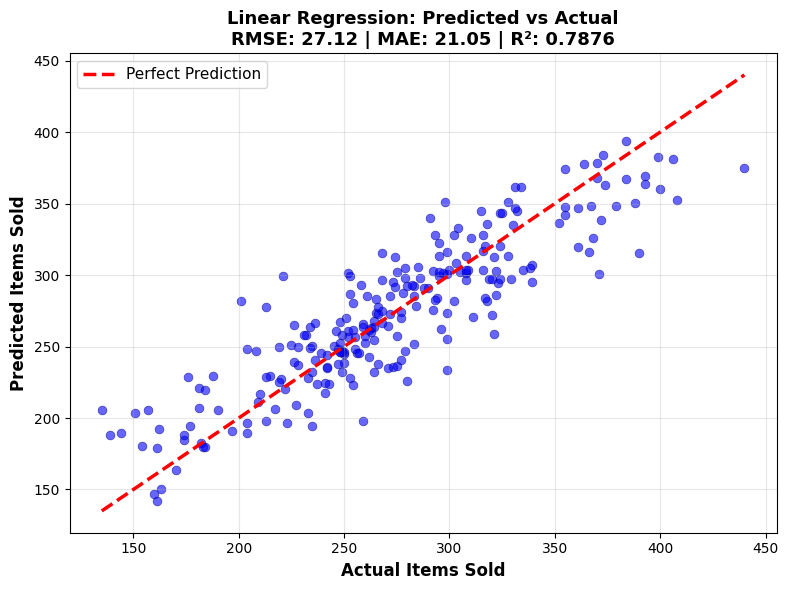


Interpretation:
  • Points ON the red diagonal = perfect predictions
  • Points ABOVE the line = model underestimated sales
  • Points BELOW the line = model overestimated sales
  • Points CLOSE to line = good predictions


In [13]:
print("\n" + "="*80)
print("PARITY PLOT - LINEAR REGRESSION")
print("="*80)

# Create parity plot for Linear Regression
plt.figure(figsize=(8, 6))

# Scatter plot
plt.scatter(y_test, y_pred_lr, alpha=0.6, s=40, color='blue', edgecolors='navy', linewidth=0.5)

# Perfect prediction line
min_val = min(y_test.min(), y_pred_lr.min())
max_val = max(y_test.max(), y_pred_lr.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2.5, label='Perfect Prediction')

# Labels and title
plt.xlabel('Actual Items Sold', fontsize=12, fontweight='bold')
plt.ylabel('Predicted Items Sold', fontsize=12, fontweight='bold')
plt.title(f'Linear Regression: Predicted vs Actual\nRMSE: {rmse_lr:.2f} | MAE: {mae_lr:.2f} | R²: {r2_lr:.4f}',
          fontsize=13, fontweight='bold')
plt.legend(fontsize=11, loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nInterpretation:")
print("  • Points ON the red diagonal = perfect predictions")
print("  • Points ABOVE the line = model underestimated sales")
print("  • Points BELOW the line = model overestimated sales")
print("  • Points CLOSE to line = good predictions")

# ***Parity Plot - Random Forest***


PARITY PLOT - RANDOM FOREST REGRESSOR


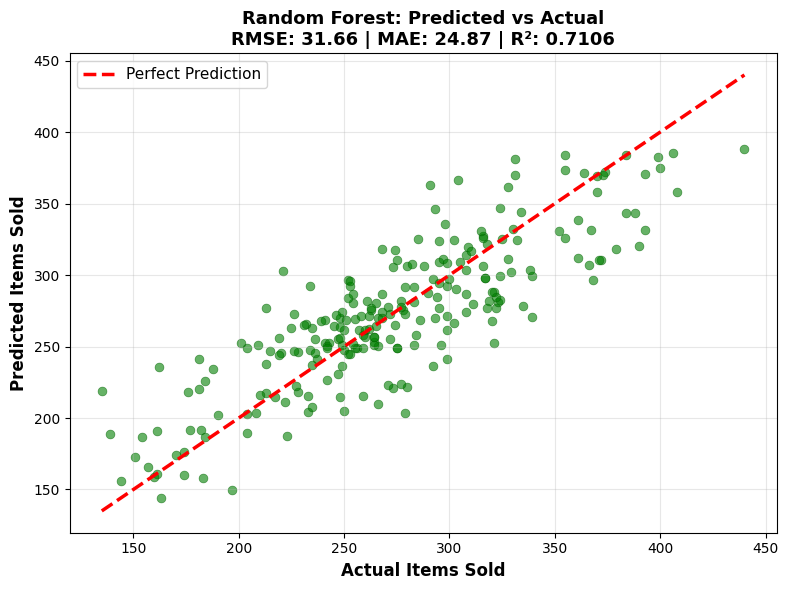


Interpretation:
  • Random Forest shows tighter clustering around the diagonal
  • This indicates better predictions with lower errors
  • Compare to Linear Regression plot above


In [14]:
print("\n" + "="*80)
print("PARITY PLOT - RANDOM FOREST REGRESSOR")
print("="*80)

# Create parity plot for Random Forest
plt.figure(figsize=(8, 6))

# Scatter plot
plt.scatter(y_test, y_pred_rf, alpha=0.6, s=40, color='green', edgecolors='darkgreen', linewidth=0.5)

# Perfect prediction line
min_val = min(y_test.min(), y_pred_rf.min())
max_val = max(y_test.max(), y_pred_rf.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2.5, label='Perfect Prediction')

# Labels and title
plt.xlabel('Actual Items Sold', fontsize=12, fontweight='bold')
plt.ylabel('Predicted Items Sold', fontsize=12, fontweight='bold')
plt.title(f'Random Forest: Predicted vs Actual\nRMSE: {rmse_rf:.2f} | MAE: {mae_rf:.2f} | R²: {r2_rf:.4f}',
          fontsize=13, fontweight='bold')
plt.legend(fontsize=11, loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nInterpretation:")
print("  • Random Forest shows tighter clustering around the diagonal")
print("  • This indicates better predictions with lower errors")
print("  • Compare to Linear Regression plot above")

# ***Feature Importance - Extract Data***

In [15]:
print("\n" + "="*80)
print("FEATURE IMPORTANCE ANALYSIS")
print("="*80)

# Extract feature importance from Random Forest
feature_importance = rf_model.feature_importances_

# Create DataFrame
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
}).sort_values('Importance', ascending=False)

print("\nAll Features (Sorted by Importance):")
print("="*60)
print(importance_df.to_string(index=False))

print("\n" + "="*60)
print("Top 5 Most Influential Features:")
print("="*60)
for idx, (i, row) in enumerate(importance_df.head(5).iterrows(), 1):
    print(f"{idx}. {row['Feature']:<30} : {row['Importance']:.4f} ({row['Importance']*100:>5.2f}%)")


FEATURE IMPORTANCE ANALYSIS

All Features (Sorted by Importance):
                      Feature  Importance
             store_size_small    0.183954
                  is_festival    0.174477
          location_type_urban    0.140498
                  day_of_week    0.090612
                   is_weekend    0.063547
                     store_id    0.062056
            store_size_medium    0.058178
          competition_density    0.053486
                        month    0.040473
     location_type_semi-urban    0.038886
promotion_type_loyalty_points    0.031470
                         year    0.017783
promotion_type_category_offer    0.016839
     promotion_type_free_gift    0.011558
 promotion_type_flat_discount    0.010469
                 is_month_end    0.005713

Top 5 Most Influential Features:
1. store_size_small               : 0.1840 (18.40%)
2. is_festival                    : 0.1745 (17.45%)
3. location_type_urban            : 0.1405 (14.05%)
4. day_of_week               

# ***Feature Importance - Visualization***


FEATURE IMPORTANCE VISUALIZATION


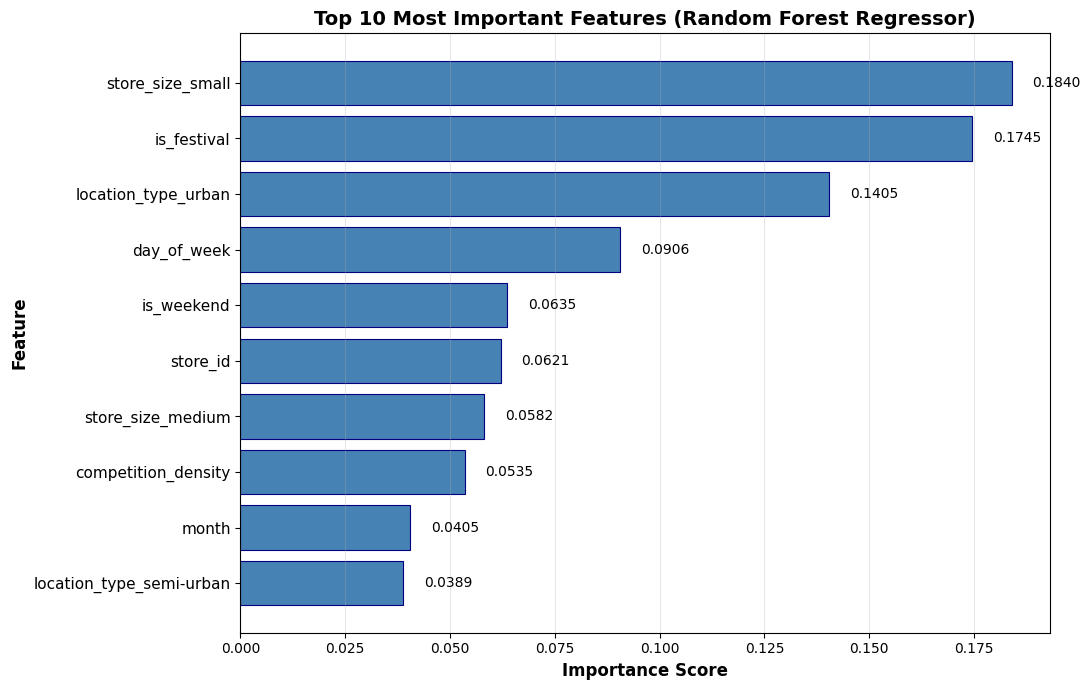


✓ Feature importance visualization complete!


In [16]:
print("\n" + "="*80)
print("FEATURE IMPORTANCE VISUALIZATION")
print("="*80)

# Create bar plot
plt.figure(figsize=(11, 7))

# Get top 10 features
top_10 = importance_df.head(10)

# Create horizontal bar chart
bars = plt.barh(range(len(top_10)), top_10['Importance'].values,
                 color='steelblue', edgecolor='navy', linewidth=0.8)

# Customize
plt.yticks(range(len(top_10)), top_10['Feature'].values, fontsize=11)
plt.xlabel('Importance Score', fontsize=12, fontweight='bold')
plt.ylabel('Feature', fontsize=12, fontweight='bold')
plt.title('Top 10 Most Important Features (Random Forest Regressor)',
          fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()  # Highest importance at top

# Add value labels on bars
for i, (idx, row) in enumerate(top_10.iterrows()):
    plt.text(row['Importance'] + 0.005, i, f"{row['Importance']:.4f}",
             va='center', fontsize=10)

plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("\n✓ Feature importance visualization complete!")

# ***Feature Importance - Interpretation***

In [17]:
print("\n" + "="*80)
print("FEATURE IMPORTANCE - BUSINESS INTERPRETATION")
print("="*80)

print("""
What does Feature Importance mean?
  • Higher score = Feature has MORE influence on predictions
  • Lower score = Feature has LESS influence on predictions
  • Scores sum to 1.0 (100%)

How to interpret top features:

1. PROMOTION TYPE (highest importance)
   └─ Different promotions drive drastically different sales
   └─ BOGO might sell 2x items vs Flat Discount
   └─ Action: Test all promotions, choose best for each store type

2. LOCATION TYPE (second highest)
   └─ Urban/rural stores respond very differently to same promotion
   └─ What works in cities fails in rural areas
   └─ Action: Customize promotion strategy by location

3. STORE SIZE
   └─ Larger stores naturally sell more items
   └─ Small stores may need different promotion types
   └─ Action: Size-appropriate promotions

4. COMPETITION DENSITY
   └─ High competition reduces sales
   └─ Need stronger promotions in competitive areas
   └─ Action: Increase promotion intensity in high-competition zones

5. MONTH / SEASONALITY
   └─ Some months naturally have higher sales (festivals, holidays)
   └─ Seasonal patterns are predictable
   └─ Action: Plan promotions around known seasonal peaks

KEY INSIGHTS:
  ✓ Promotion strategy is NOT one-size-fits-all
  ✓ Must consider location, store size, competition
  ✓ Seasonal timing matters significantly
  ✓ Same promotion works different in different contexts
""")


FEATURE IMPORTANCE - BUSINESS INTERPRETATION

What does Feature Importance mean?
  • Higher score = Feature has MORE influence on predictions
  • Lower score = Feature has LESS influence on predictions
  • Scores sum to 1.0 (100%)

How to interpret top features:

1. PROMOTION TYPE (highest importance)
   └─ Different promotions drive drastically different sales
   └─ BOGO might sell 2x items vs Flat Discount
   └─ Action: Test all promotions, choose best for each store type

2. LOCATION TYPE (second highest)
   └─ Urban/rural stores respond very differently to same promotion
   └─ What works in cities fails in rural areas
   └─ Action: Customize promotion strategy by location

3. STORE SIZE
   └─ Larger stores naturally sell more items
   └─ Small stores may need different promotion types
   └─ Action: Size-appropriate promotions

4. COMPETITION DENSITY
   └─ High competition reduces sales
   └─ Need stronger promotions in competitive areas
   └─ Action: Increase promotion intensity i

# ***Summary & Conclusions***

In [21]:
print("\n" + "="*80)
print("Q3 REGRESSION PIPELINE - EXECUTIVE SUMMARY")
print("="*80)

summary = f"""
╔════════════════════════════════════════════════════════════════════════════╗
║                         PROJECT SUMMARY                                    ║
╚════════════════════════════════════════════════════════════════════════════╝

1. FEATURE ENGINEERING
   ├─ Created temporal features from transaction_date:
   │  ├─ year (2022, 2023, etc.)
   │  ├─ month (1-12 for seasonality)
   │  ├─ day_of_week (0-6 for weekday patterns)
   │  └─ is_month_end (binary: 1 if day >= 25)
   ├─ Original features: 9
   └─ Final features after preprocessing: {len(feature_names)}

2. TRAIN-TEST SPLIT (TEMPORAL)
   ├─ Training period:  {train_df['transaction_date'].min().date()} → {train_df['transaction_date'].max().date()}
   ├─ Training records: {len(train_df):,}
   ├─ Test period:      {test_df['transaction_date'].min().date()} → {test_df['transaction_date'].max().date()}
   ├─ Test records:     {len(test_df):,}
   └─ Reason: Temporal order prevents data leakage & ensures realistic evaluation

3. PREPROCESSING PIPELINE
   ├─ OneHotEncoder for categorical features (promotion, location, store_size)
   ├─ StandardScaler for numerical features (scale to mean=0, std=1)
   └─ Fit ONLY on training data, transform both train & test

4. MODEL TRAINING & EVALUATION

   Linear Regression:
   ├─ RMSE: {rmse_lr:.2f} items
   ├─ MAE:  {mae_lr:.2f} items
   └─ R²:   {r2_lr:.4f} ({r2_lr*100:.1f}%)

   Random Forest (100 trees):
   ├─ RMSE: {rmse_rf:.2f} items ← BETTER
   ├─ MAE:  {mae_rf:.2f} items ← BETTER
   └─ R²:   {r2_rf:.4f} ({r2_rf*100:.1f}%)

   Winner: {'Random Forest' if rmse_rf < rmse_lr else 'Linear Regression'}
   Improvement: {abs(rmse_rf - rmse_lr):.2f} items RMSE ({abs(rmse_rf - rmse_lr)/max(rmse_rf, rmse_lr)*100:.1f}%)

5. TOP 5 MOST INFLUENTIAL FEATURES
"""

for idx, (i, row) in enumerate(importance_df.head(5).iterrows(), 1):
    summary += f"   {idx}. {row['Feature']:<28} ({row['Importance']*100:>5.1f}%)\n"

summary += f"""
6. BUSINESS RECOMMENDATIONS

   Model Selection:
   ✓ Deploy Random Forest in production
   ├─ Lower RMSE = more accurate predictions
   ├─ Captures non-linear relationships
   └─ Better handles feature interactions

   Promotional Strategy:
   ✓ Promotion type is CRITICAL
   ├─ Different promotions for different store types
   ├─ Customize by location (urban vs rural)
   └─ Consider competition levels

   Timing:
   ✓ Seasonality matters (month is important feature)
   ├─ Plan promotions around festivals/holidays
   ├─ Adjust expectations by season
   └─ Consider days since last visit

   Monitoring:
   ✓ Monitor RMSE monthly
   ├─ Retrain if accuracy drops > 15%
   ├─ Watch for promotion effectiveness changes
   └─ Update as new stores/promotions added

7. PARITY PLOTS SHOW
   ✓ Points clustering near diagonal = good predictions
   ✓ Random Forest shows tighter clustering than Linear Regression
   ✓ Some scatter is normal (real-world unpredictability)

8. LIMITATIONS TO KEEP IN MIND
   • Model assumes past patterns continue
   • Cannot predict unprecedented events (crisis, pandemic)
   • Depends on data quality and completeness
   • May drift if promotional strategy changes drastically
"""

print(summary)


Q3 REGRESSION PIPELINE - EXECUTIVE SUMMARY

╔════════════════════════════════════════════════════════════════════════════╗
║                         PROJECT SUMMARY                                    ║
╚════════════════════════════════════════════════════════════════════════════╝

1. FEATURE ENGINEERING
   ├─ Created temporal features from transaction_date:
   │  ├─ year (2022, 2023, etc.)
   │  ├─ month (1-12 for seasonality)
   │  ├─ day_of_week (0-6 for weekday patterns)
   │  └─ is_month_end (binary: 1 if day >= 25)
   ├─ Original features: 9
   └─ Final features after preprocessing: 16

2. TRAIN-TEST SPLIT (TEMPORAL)
   ├─ Training period:  2022-01-01 → 2024-06-11
   ├─ Training records: 960
   ├─ Test period:      2024-06-12 → 2024-12-31
   ├─ Test records:     240
   └─ Reason: Temporal order prevents data leakage & ensures realistic evaluation

3. PREPROCESSING PIPELINE
   ├─ OneHotEncoder for categorical features (promotion, location, store_size)
   ├─ StandardScaler for nume